In [1]:
import polars as pl
import matplotlib.pyplot as plt
import psycopg2
from dotenv import load_dotenv
load_dotenv('/home/luifer/Numbersdontlie/Data-Science-Piscine/day2/ex00/.env', override=True)
import os
# import seaborn as sns
# import altair as alt
# alt.data_transformers.enable("vegafusion")
import vegafusion as vf

In [2]:
# load the env and generate connection details
user = os.getenv('POSTGRES_USER')
password = os.getenv('POSTGRES_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('POSTGRES_DB')

uri = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"

In [3]:
# generate the query to get # of customers monthly
query = """
SELECT *
FROM customers
WHERE event_type = 'purchase'
ORDER BY event_time ASC;
"""


In [4]:
# generate the dataframe
with psycopg2.connect(
    user=user,
    password=password,
    host=host,
    port=port,
    dbname=dbname,
) as conn:
    df_purchase = pl.read_database(
        query,
        conn,
        infer_schema_length=10_000,
        schema_overrides={
            "product_id": pl.Int64,
            "user_id": pl.Int64,
            "price": pl.Float64,
        },
    )


In [7]:
df_purchase.head(10)

event_time,event_type,product_id,price,user_id,user_session,category_id,category_code,brand
"datetime[μs, UTC]",str,i64,f64,i64,str,i64,str,str
2022-10-01 00:06:35 UTC,"""purchase""",5696184,2.38,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null
2022-10-01 00:06:35 UTC,"""purchase""",5865795,1.75,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null
2022-10-01 00:06:35 UTC,"""purchase""",5814822,2.38,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null
2022-10-01 00:06:35 UTC,"""purchase""",5619866,2.86,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null
2022-10-01 00:06:35 UTC,"""purchase""",5619862,5.32,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null
2022-10-01 00:06:35 UTC,"""purchase""",5875317,1.59,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null
2022-10-01 00:06:35 UTC,"""purchase""",5706784,4.44,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null
2022-10-01 00:06:35 UTC,"""purchase""",5723503,2.62,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null
2022-10-01 00:06:35 UTC,"""purchase""",5773207,2.62,474232307,"""445f2b74-5e4c-427e-b7fa-6e0a28…",null,null,null


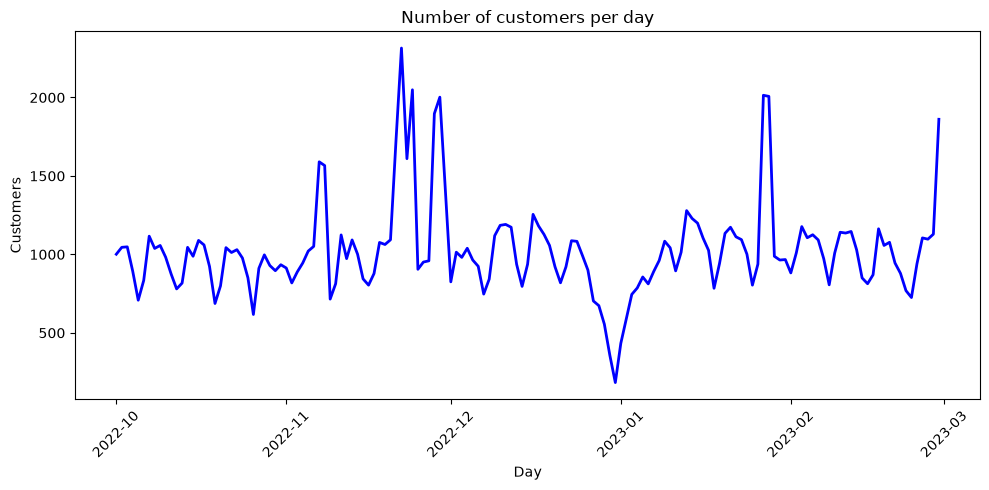

In [ ]:
# Graph 1: daily count of customers over time
df_daily_customers = (
    df_purchase
    .group_by("price")
    .agg(pl.col("user_id").n_unique().alias("customers"))
    .sort("day")
)

plt.figure(figsize=(10, 5))
plt.plot(
    df_daily_customers["day"].to_list(),
    df_daily_customers["customers"].to_list(),
    linewidth=2,
    color="blue",
)
plt.title("Number of customers per day")
plt.xlabel("Day")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
#testing a new dataframe
df_monthly_sales = (
    df_purchase
    .with_columns(
        pl.col("event_time").dt.truncate("1mo").alias("month")
    )
    .group_by("month")
    .agg(
        [
            pl.col("price").sum().alias("total_sales_millions"),
            pl.col("user_id").n_unique().alias("unique_customers"),
        ]
    )
    .with_columns(
        pl.col("total_sales_millions") / pl.col("unique_customers").alias("avg_sales_per_customer")
    )
    .sort("month")
)

In [13]:
df_monthly_sales.head(10)

month,total_sales_millions,unique_customers
"datetime[μs, UTC]",f64,u32
2022-10-01 00:00:00 UTC,46.98261,25762
2022-11-01 00:00:00 UTC,48.545959,31524
2022-12-01 00:00:00 UTC,42.054034,25613
2023-01-01 00:00:00 UTC,46.801198,28220
2023-02-01 00:00:00 UTC,46.813679,25759


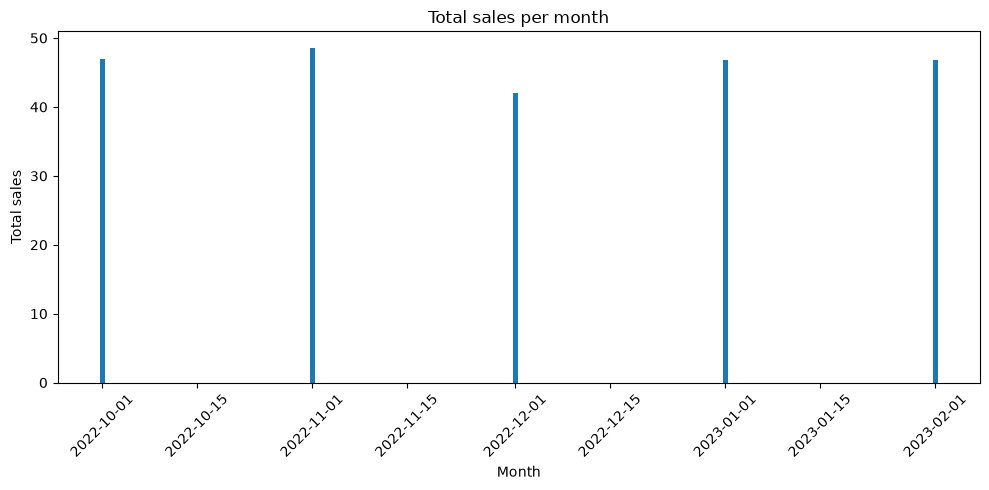

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(
    df_monthly_sales["month"],
    df_monthly_sales["total_sales_millions"],
)
plt.title("Total sales per month")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# Graph 2: histogram of total sales in millions per month
df_monthly_sales = (
    df_purchase
    .with_columns(pl.col("event_time").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg((pl.col("price").sum()/1_000_000).alias("total_sales_millions"))
)

plt.figure(figsize=(10, 5))
plt.bar(
    df_monthly_sales["month_label"],
    df_monthly_sales["total_sales_millions"],
)
plt.title("Total sales per month")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


ColumnNotFoundError: "month_label" not found

<Figure size 1000x500 with 0 Axes>

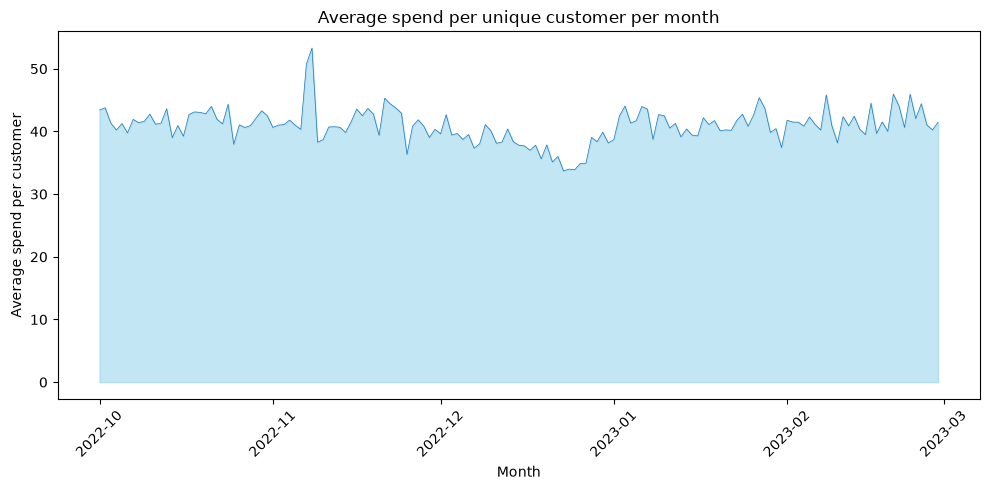

In [24]:
# Graph 3: average spend per unique customer per month
# create the dataframe with the data for the graph
df_avg_spend = (
    df_purchase
    .with_columns(pl.col("event_time").dt.truncate("1d").alias("month"))
    .group_by("month")
    .agg([
        pl.col("price").sum().alias("total_sales"),
        pl.col("user_id").n_unique().alias("unique_customers"),
    ])
    .with_columns((pl.col("total_sales") / pl.col("unique_customers")).alias("avg_spend_per_customer"))
    .sort("month")
)

# set the x and y values for the graph
x = df_avg_spend["month"].to_list()
y = df_avg_spend["avg_spend_per_customer"].to_list()

# plot the graph
plt.figure(figsize=(10, 5))
plt.fill_between(x, y, color="skyblue", alpha=0.5)
plt.plot(x, y, linewidth=0.5)
plt.title("Average spend per unique customer per month")
plt.xlabel("Month")
plt.ylabel("Average spend per customer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()